<a href="https://colab.research.google.com/github/RosarioH10062002/connectivity-biomarkers-pd-depression/blob/main/Final_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LIBRARIES**

In [596]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from pathlib import Path
import re
import inspect
import math
from collections import Counter
from scipy.io import loadmat,savemat
import scipy.io as sio
try:
    import nilearn
    from nilearn import image as nimg
    from nilearn import plotting
    from nilearn.connectome import ConnectivityMeasure

except ImportError:
    !pip install nilearn
    import nilearn
    from nilearn import image as nimg
    from nilearn import plotting
    from nilearn.connectome import ConnectivityMeasure
    from nilearn.plotting import plot_glass_brain, show

try:
  from neuroHarmonize import harmonizationLearn
  from neuroCombat import neuroCombat
except:
  !pip install neuroHarmonize
  !pip install neuroCombat
  from neuroHarmonize import harmonizationLearn
  from neuroCombat import neuroCombat

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

try:
  import bct
except ImportError:
  !pip install bctpy
  import bct

try:
  import networkx as nx
except ImportError:
  !pip install networkx
  import networkx as nx

try:
  import nitime
  import nitime.analysis as nta
  import nitime.timeseries as ts
  import nitime.utils as tsu
  from nitime.analysis import GrangerAnalyzer
  from nitime.timeseries import TimeSeries
  from nitime.viz import drawmatrix_channels

except ImportError:
  !pip install nitime
  import nitime
  import nitime.analysis as nta
  import nitime.timeseries as ts
  import nitime.utils as tsu
  from nitime.viz import drawmatrix_channels

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**LOAD DATA**

In [597]:
ROOT_PATH = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/python_to_matlab")

In [598]:
root_path_pd = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_PD")
root_path_pd_dep = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_PD_DEP")
root_path_ctrl = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_CTRL")
all_participants_path = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/all_part.csv")
all_participants = pd.read_csv(all_participants_path, sep = ",")

In [599]:
def get_dataframe(status):
  if status == "PARTICIPANTS":
    df = pd.read_csv(all_participants_path, sep = ",")
  return df
def clean_df(all_participants):
  all_participants = all_participants[all_participants["Description"].str.startswith("rsfMRI_RL")]
  filtered_df = all_participants.drop_duplicates(subset = "Subject ID")
  return filtered_df

def get_manufacturer(list_participants, status):
  raw_participants = pd.read_csv(all_participants_path)
  all_participants = clean_df(raw_participants)
  list_d = [int(x) for x in list_participants if x.isdigit()]
  mask = all_participants["Subject ID"].isin(list_d)
  filtered_df = all_participants[mask]
  df_siemens = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=SIEMENS;TR=2500.0"]
  df_philips = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=Philips Medical Systems;TR=2500.0"]
  df_ge = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0"]
  print(f"{status}  = Siemens: {df_siemens.shape[0]}, Philips: {df_philips.shape[0]}, GE:{df_ge.shape[0]}")
  return df_siemens, df_philips, df_ge

In [600]:
raw_participants = pd.read_csv(all_participants_path)
all_participants = clean_df(raw_participants)
all_participants[all_participants["Description"] == "rsfMRI_RL_split_2"]

,Subject ID,Sex,Research Group,Age,GDSCALE Total Score,Modality,Description,Imaging Protocol


In [601]:
raw_participants = pd.read_csv(all_participants_path)
all_participants = clean_df(raw_participants)
all_siemens = all_participants[all_participants["Imaging Protocol"] == "Manufacturer=SIEMENS;TR=2500.0"]
print(f"Siemens: {all_siemens.shape}")
all_philips = all_participants[all_participants["Imaging Protocol"] == "Manufacturer=Philips Medical Systems;TR=2500.0"]
print(f"Philips: {all_philips.shape}")
all_ge = all_participants[all_participants["Imaging Protocol"] == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0"]
print(f"GE Medical Systems: {all_ge.shape}")

def segment_groups(df,name):
  df_pd = df[(df["Research Group"] == "PD") & (df["GDSCALE Total Score"] < 5)]
  df_pd_dep = df[(df["Research Group"] == "PD") & (df["GDSCALE Total Score"] >= 5)]
  #df_pd_dep = df[df["Research Group"] == "PD"]
  df_ctrl = df[df["Research Group"] == "Control"]
  print(f"Name: {name}")
  print(f"PD: {df_pd.shape[0]}, PD_DEP: {df_pd_dep.shape[0]}, CTRL: {df_ctrl.shape[0]}")
  return df_pd, df_ctrl, df_pd_dep

df_pd_siemens, df_ctrl_siemens, df_pdd_siemens = segment_groups(df = all_siemens, name = "Siemens")
df_pd_philips, df_ctrl_philips, df_pdd_philips = segment_groups(df = all_philips, name = "Philips")
df_pd_ge, df_ctrl_ge, df_pdd_ge = segment_groups(df = all_ge, name = "GE")

# Total 176, 31, 40

Siemens: (179, 8)
Philips: (57, 8)
GE Medical Systems: (48, 8)
Name: Siemens
PD: 129, PD_DEP: 21, CTRL: 25
Name: Philips
PD: 28, PD_DEP: 6, CTRL: 5
Name: GE
PD: 19, PD_DEP: 4, CTRL: 10


In [602]:
list_participants_pd = os.listdir(root_path_pd)
df_siemens_pd, df_philips_pd, df_ge_pd = get_manufacturer(list_participants_pd, status = "PD")

list_participants_pdd = os.listdir(root_path_pd_dep)
df_siemens_pdd, df_philips_pdd, df_ge_pdd = get_manufacturer(list_participants_pdd, status = "PDD")

list_participants_ctrl = os.listdir(root_path_ctrl)
df_siemens_ctrl, df_philips_ctrl, df_ge_ctrl = get_manufacturer(list_participants_ctrl, status = "CTRL")

PD  = Siemens: 24, Philips: 4, GE:4
PDD  = Siemens: 18, Philips: 4, GE:4
CTRL  = Siemens: 24, Philips: 4, GE:4


In [603]:
def get_new_participants(total_list, actual_list):
  mask_new_participants = ~total_list["Subject ID"].isin(actual_list["Subject ID"])
  return total_list[mask_new_participants]

In [478]:
get_new_participants(total_list = df_pdd_siemens, actual_list = df_siemens_pdd).sort_values(by = "GDSCALE Total Score", ascending = True) ##

,Subject ID,Sex,Research Group,Age,GDSCALE Total Score,Modality,Description,Imaging Protocol
15,100012,F,PD,67.0,5.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
545,141135,M,PD,53.2,5.0,fMRI,rsfMRI_RL_split_1,Manufacturer=SIEMENS;TR=2500.0
328,110219,M,PD,73.2,7.0,fMRI,"rsfMRI_RL (no music, awake, eyes open)",Manufacturer=SIEMENS;TR=2500.0


In [479]:
get_new_participants(total_list = df_pd_siemens, actual_list = df_siemens_pd).sort_values(by = "GDSCALE Total Score", ascending = True).head(10) ##

,Subject ID,Sex,Research Group,Age,GDSCALE Total Score,Modality,Description,Imaging Protocol
301,107099,M,PD,63.9,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
169,101482,M,PD,59.5,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
486,136681,M,PD,54.5,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
473,133486,M,PD,61.0,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
455,130013,M,PD,64.4,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
445,127741,M,PD,70.1,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
407,116870,M,PD,51.0,0.0,fMRI,rsfMRI_RL_split_1,Manufacturer=SIEMENS;TR=2500.0
429,121626,M,PD,76.9,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
461,130156,M,PD,61.7,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
681,152031,M,PD,77.9,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0


In [604]:
def get_manufacturers_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_manufacturer = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                protocol = all_participants.loc[subj, "Imaging Protocol"]
                list_manufacturer.append(protocol)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_manufacturer)

In [605]:
def get_missing_participants(raw_participants, status,  manufacturer, depressed):
  all_participants = clean_df(raw_participants)
  if depressed == True:
    all_participants = all_participants[all_participants["GDSCALE Total Score"] >= 5.0] #depressed status

  mask_status = all_participants["Research Group"] == status
  mask_manufacturer = all_participants["Imaging Protocol"] == f"Manufacturer={manufacturer};TR=2500.0"

  filtered_df = all_participants[
      mask_status & mask_manufacturer
  ]
  filtered_df = filtered_df.sort_values(
      by="GDSCALE Total Score", ascending=False
  )
  #print(filtered_df.shape)
  df_siemens, df_philips, df_ge = get_manufacturer(list_participants_pdd, status = "PDD")
  diff_df = filtered_df[~filtered_df["Subject ID"].isin(df_siemens["Subject ID"])]
  return diff_df
#raw_participants = pd.read_csv(all_participants_path)
#get_missing_participants(raw_participants, status = "PD",  manufacturer = "SIEMENS", depressed = True)

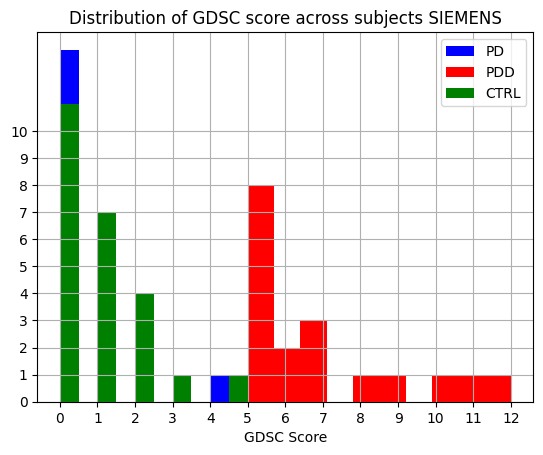

In [606]:
plt.hist(df_siemens_pd["GDSCALE Total Score"], label = "PD", color = "blue")
plt.hist(df_siemens_pdd["GDSCALE Total Score"], label = "PDD", color = "red")
plt.hist(df_siemens_ctrl["GDSCALE Total Score"], label = "CTRL", color = "green")
plt.legend()
plt.title("Distribution of GDSC score across subjects SIEMENS")
plt.xticks(np.arange(0,13))
plt.yticks(np.arange(0,11))
plt.xlabel("GDSC Score")
plt.grid(True)
plt.show()

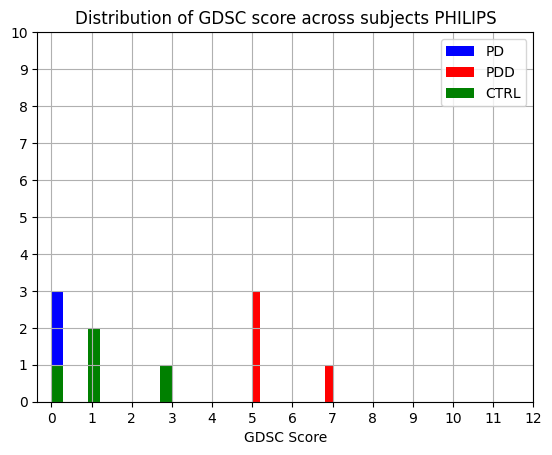

In [607]:
plt.hist(df_philips_pd["GDSCALE Total Score"], label = "PD", color = "blue")
plt.hist(df_philips_pdd["GDSCALE Total Score"], label = "PDD", color = "red")
plt.hist(df_philips_ctrl["GDSCALE Total Score"], label = "CTRL", color = "green")
plt.legend()
plt.title("Distribution of GDSC score across subjects PHILIPS")
plt.xticks(np.arange(0,13))
plt.yticks(np.arange(0,11))
plt.xlabel("GDSC Score")
plt.grid(True)
plt.show()

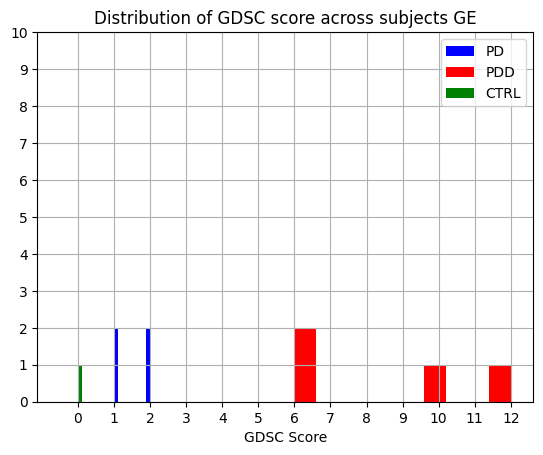

In [608]:
plt.hist(df_ge_pd["GDSCALE Total Score"], label = "PD", color = "blue")
plt.hist(df_ge_pdd["GDSCALE Total Score"], label = "PDD", color = "red")
plt.hist(df_ge_ctrl["GDSCALE Total Score"], label = "CTRL", color = "green")
plt.legend()
plt.title("Distribution of GDSC score across subjects GE")
plt.xticks(np.arange(0,13))
plt.yticks(np.arange(0,11))
plt.xlabel("GDSC Score")
plt.grid(True)
plt.show()

In [609]:
def get_list_paths(list_participants, root_dir):
  paths = {}
  gdsc_list= []
  for subject in list_participants:
      mat_path = (
          root_dir
          / str(subject)
          / str(subject)
          / "data"
          / "ROI_Subject001_Session001.mat"
      )
      paths[subject] = mat_path
      gdsc = all_participants[all_participants["Subject ID"]==int(subject)]["GDSCALE Total Score"].iloc[0]
      if math.isnan(gdsc):
        gdsc = 0
      gdsc_list.append(int(gdsc))
      #print(gdsc)
      #print(subject, "->", mat_path.exists())
  return paths, gdsc_list

In [610]:
paths, gdsc_ctrl = get_list_paths(list_participants_ctrl, root_path_ctrl)
paths, gdsc_pd = get_list_paths(list_participants_pd, root_path_pd)
paths, gdsc_pdd = get_list_paths(list_participants_pdd, root_path_pd_dep)

In [611]:
#@title EXTRACT THE REGIONS OF INTEREST
def get_individual_roi_matrix(path_name):
  path_try = loadmat(path_name)
  names = path_try["names"]
  data = path_try["data"]
  roi_names = [n[0] if isinstance(n, np.ndarray) else n for n in names[0]]
  #roi_names
  roi_idx = [
      i for i, name in enumerate(roi_names)
      if name.startswith(("networks.DefaultMode.",
                          "networks.Salience.",
                          "networks.FrontoParietal."))
  ]
  roi_interest_names = [roi_names[i] for i in roi_idx]
  roi_interest_data = [data[0, i] for i in roi_idx]
  X_interest = np.column_stack([np.asarray(arr).squeeze() for arr in roi_interest_data])
  #print("X_interest shape:", X_interest.shape)
  return X_interest, roi_interest_names

In [612]:
def get_list_roi_matrix(status):
  X_list = []
  if status ==  "PD":
    path_names, gdsc = get_list_paths(list_participants_pd, root_path_pd)
  if status ==  "PDD":
    path_names, gdsc = get_list_paths(list_participants_pdd, root_path_pd_dep)
  if status ==  "CTRL":
    path_names, gdsc = get_list_paths(list_participants_ctrl, root_path_ctrl)

  for path in path_names.values():
    X_interest, roi_interest_names = get_individual_roi_matrix(path)
    X_list.append(X_interest)
  return X_list, roi_interest_names

#**Functional Connectivity**

In [613]:
#@title STATIC FUNCTIONAL CONNECTIVITY
def compute_fc_matrix(status):
  fc_matrix_list = []
  X_list,roi_interest_names = get_list_roi_matrix(status)
  for x in X_list:
    fc_matrix = np.corrcoef(x.T)
    fc_matrix = np.clip(fc_matrix, -0.999999, 0.999999)
    fc_matrix = np.arctanh(fc_matrix)
    np.fill_diagonal(fc_matrix, 0)
    fc_matrix_list.append(fc_matrix)
  return np.array(fc_matrix_list)

def flatten_fc(matrix):
  return matrix[np.triu_indices_from(matrix, k = 1)]

def get_all_flatten(matrix_list):
  matrix_flatten = []
  for matrix in matrix_list:
    temp_matrix = flatten_fc(matrix)
    matrix_flatten.append(temp_matrix)
  return np.array(matrix_flatten)

In [614]:
fc_matrix_list_pd = compute_fc_matrix(status = "PD")
matrix_flatten_pd = get_all_flatten(fc_matrix_list_pd)

print(fc_matrix_list_pd.shape)
print(matrix_flatten_pd.shape)
fc_matrix_list_pdd = compute_fc_matrix(status = "PDD")
matrix_flatten_pdd = get_all_flatten(fc_matrix_list_pdd)
print(fc_matrix_list_pdd.shape)
print(matrix_flatten_pdd.shape)
fc_matrix_list_ctrl = compute_fc_matrix(status = "CTRL")
matrix_flatten_ctrl = get_all_flatten(fc_matrix_list_ctrl)
print(fc_matrix_list_ctrl.shape)
print(matrix_flatten_ctrl.shape)

(32, 15, 15)
(32, 105)
(26, 15, 15)
(26, 105)
(32, 15, 15)
(32, 105)


In [491]:
#@title Combat Harmonization Variables
X = np.vstack([matrix_flatten_pd,matrix_flatten_pdd,matrix_flatten_ctrl])
group = ["PD"]*len(list_participants_pd) + ["PDD"]*len(list_participants_pdd) + ["CTRL"]* len(list_participants_ctrl)

batch_pd = get_manufacturers_list(list_participants_pd)
batch_pdd = get_manufacturers_list(list_participants_pdd)
batch_ctrl = get_manufacturers_list(list_participants_ctrl)
batch = np.concatenate([batch_pd, batch_pdd, batch_ctrl])
#batch_two = np.where(batch == "Manufacturer=Philips Medical Systems;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch)
#batch_two = np.where(batch_two == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch_two)

print(X.shape)
print(len(group))
print(len(batch))

(90, 105)
90
90


In [492]:
covars = pd.DataFrame({
    "SITE": batch,
    "GROUP": pd.Categorical(group).codes # 0 = ctrl, 1 = pd, 2 = pdd
})
#print(covars.head())
model, X_harmonized = harmonizationLearn(
    data = X,
    covars = covars
)

In [493]:
print(X.shape, X_harmonized.shape)
print(np.isnan(X_harmonized).sum(), np.isinf(X_harmonized).sum())

(90, 105) (90, 105)
0 0


In [494]:
def statistical_test(X, index_1, index_2):
  p_values = []
  X_harmonized = X
  for i in range(X_harmonized.shape[1]):
      x1 = X_harmonized[index_1, i]
      x2 = X_harmonized[index_2, i]

      _, p = mannwhitneyu(x1, x2, alternative="two-sided")
      p_values.append(p)
  p_values = np.array(p_values)
  sig_idx_uncorrected = np.where(p_values < 0.05)[0]
  print(f"Uncorrected: {sig_idx_uncorrected}")
  list_index = sig_idx_uncorrected
  return p_values, list_index
def statistical_correction(p_values):
  multipletests(p_values, method="fdr_bh")
  reject, p_fdr, _, _ = multipletests(p_values, alpha=0.1, method="fdr_tsbh")
  print("Significant after FDR:", reject.sum())

def get_roi_names():
  X_list, roi_interest_names = get_list_roi_matrix(status = "PD")
  return roi_interest_names
def get_connection(list_index):
  dataframe = pd.DataFrame()
  n_rois = 15
  roi_interest_names = get_roi_names()
  matrix = np.zeros((len(roi_interest_names), len(roi_interest_names)), dtype = int)
  triu_idx = np.triu_indices(n_rois, k=1)

  connections = [
      (triu_idx[0][i], triu_idx[1][i])
      for i in list_index
  ]

  #print(connections)
  for i, j in connections:
      print(roi_interest_names[i], "<->", roi_interest_names[j])
      matrix[i,j] = 1

  matrix = matrix + matrix.T
  return matrix

In [495]:
def save_to_plot(connection_matrix, coordinates, labels, name):
  savemat(ROOT_PATH/f"{name}.mat",{"CM": connection_matrix, "coord": coordinates, "labels": labels})

In [496]:
roi_names = get_roi_names()
roi_names


[np.str_('networks.DefaultMode.MPFC (1,55,-3)'),
 np.str_('networks.DefaultMode.LP (L) (-39,-77,33)'),
 np.str_('networks.DefaultMode.LP (R) (47,-67,29)'),
 np.str_('networks.DefaultMode.PCC (1,-61,38)'),
 np.str_('networks.Salience.ACC (0,22,35)'),
 np.str_('networks.Salience.AInsula (L) (-44,13,1)'),
 np.str_('networks.Salience.AInsula (R) (47,14,0)'),
 np.str_('networks.Salience.RPFC (L) (-32,45,27)'),
 np.str_('networks.Salience.RPFC (R) (32,46,27)'),
 np.str_('networks.Salience.SMG (L) (-60,-39,31)'),
 np.str_('networks.Salience.SMG (R) (62,-35,32)'),
 np.str_('networks.FrontoParietal.LPFC (L)  (-43,33,28)'),
 np.str_('networks.FrontoParietal.PPC (L)  (-46,-58,49)'),
 np.str_('networks.FrontoParietal.LPFC (R)  (41,38,30)'),
 np.str_('networks.FrontoParietal.PPC (R)  (52,-52,45)')]

In [497]:
def obtain_coordinates():
  char1 = '('
  char2 = ')'
  coordinates = []
  roi_names = get_roi_names()
  for mystr in roi_names:
    coord_str = ""
    if mystr[mystr.find(char1)+1] == "L" or mystr[mystr.find(char1)+1] == "R":
      second_index = mystr.find(char1, mystr.find(char1) + 1)
      coord_str = mystr[second_index + 1 : mystr.find(char2, second_index)]
    else:
      coord_str = mystr[mystr.find(char1) + 1 : mystr.find(char2)]

    x, y, z = map(int, coord_str.split(','))
    coordinates.append((x, y, z))

  return coordinates
coordinates = obtain_coordinates()
coordinates

[(1, 55, -3),
 (-39, -77, 33),
 (47, -67, 29),
 (1, -61, 38),
 (0, 22, 35),
 (-44, 13, 1),
 (47, 14, 0),
 (-32, 45, 27),
 (32, 46, 27),
 (-60, -39, 31),
 (62, -35, 32),
 (-43, 33, 28),
 (-46, -58, 49),
 (41, 38, 30),
 (52, -52, 45)]

In [498]:
def get_list_names():
  roi_interest_names = get_roi_names()
  list_names = []
  for name in roi_interest_names:
    name = name.replace("networks.FrontoParietal","FPN").replace("networks.Salience","SAL").replace("networks.DefaultMode","DMN")
    index = name.find("(")
    if (name[index+1] == "L") or (name[index+1] == "R"):
      second_index = name.find("(", index+1)
      final_name = name[:second_index-1]
    else:
      final_name = name[:index]
    if final_name[-1] == " ":
      final_name = final_name[:-1]
      list_names.append(final_name)
    else:
      list_names.append(final_name)

  return list_names
print(get_list_names())
list_names = get_list_names()

['DMN.MPFC', 'DMN.LP (L)', 'DMN.LP (R)', 'DMN.PCC', 'SAL.ACC', 'SAL.AInsula (L)', 'SAL.AInsula (R)', 'SAL.RPFC (L)', 'SAL.RPFC (R)', 'SAL.SMG (L)', 'SAL.SMG (R)', 'FPN.LPFC (L)', 'FPN.PPC (L)', 'FPN.LPFC (R)', 'FPN.PPC (R)']


In [499]:
def get_colors(end_index):
  matplotlib_colors = list(mcolors.CSS4_COLORS.keys())
  #new_color_list = []

  #for index, color in enumerate(matplotlib_colors):
  #  new_color_list.extend([color]*2)
  return matplotlib_colors[:end_index]

In [500]:
def plot_connections(connection_matrix, coordinates, group1, group2):
  plotting.plot_connectome(
    connection_matrix,
    coordinates,
    node_size=50,
    edge_threshold = "80%",
    colorbar=False,
    annotate = True,
    display_mode = "ortho",
    title= f"Significant FC Differences ({group1} vs {group2})"
  )

  plotting.show()

Uncorrected: [ 0 78 80 81]
networks.DefaultMode.MPFC (1,55,-3) <-> networks.DefaultMode.LP (L) (-39,-77,33)
networks.Salience.RPFC (L) (-32,45,27) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.Salience.RPFC (L) (-32,45,27) <-> networks.FrontoParietal.LPFC (L)  (-43,33,28)
networks.Salience.RPFC (L) (-32,45,27) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
Significant after FDR: 0


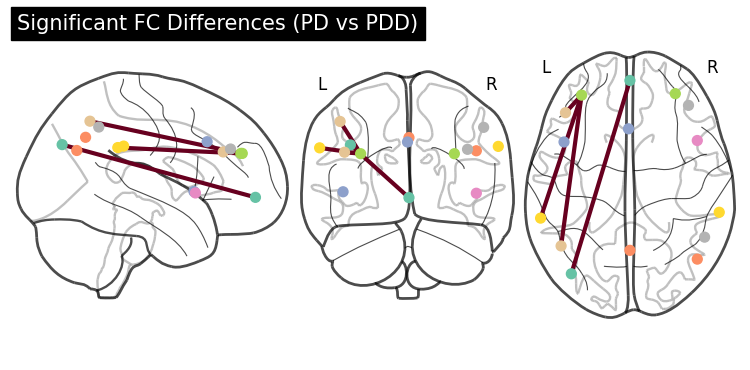

In [501]:
#@title Statistical Test PD vs PDD
group_array = np.array(group)
idx_pd = group_array == "PD"
idx_pdd = group_array == "PDD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
connection_matrix = get_connection(list_index)
coordinates = obtain_coordinates()
statistical_correction(p_values)
p_values[list_index]
#connection_matrix
#coordinates
plot_connections(connection_matrix, coordinates, group1 = "PD", group2 = "PDD")


In [502]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "FC_PD_PDD")

Uncorrected: [ 0  1  8 29 32 33 37]
networks.DefaultMode.MPFC (1,55,-3) <-> networks.DefaultMode.LP (L) (-39,-77,33)
networks.DefaultMode.MPFC (1,55,-3) <-> networks.DefaultMode.LP (R) (47,-67,29)
networks.DefaultMode.MPFC (1,55,-3) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.AInsula (L) (-44,13,1)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.RPFC (R) (32,46,27)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.FrontoParietal.LPFC (R)  (41,38,30)
Significant after FDR: 0


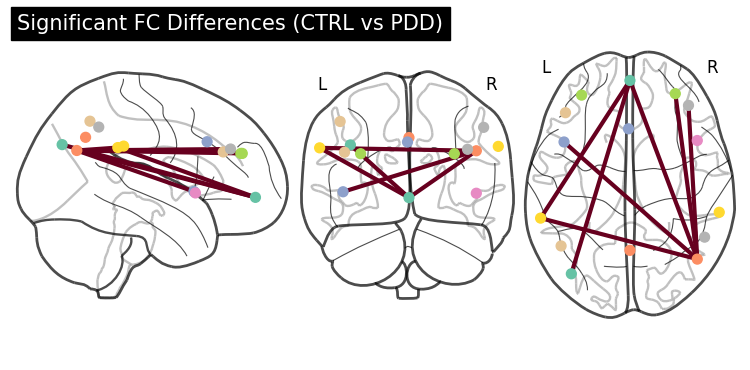

In [503]:
#@title Statistical Test CTRL vs PDD
group_array = np.array(group)
idx_pd = group_array == "CTRL"
idx_pdd = group_array == "PDD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
connection_matrix = get_connection(list_index)
coordinates = obtain_coordinates()
statistical_correction(p_values)
p_values[list_index]
#connection_matrix
#coordinates
plot_connections(connection_matrix, coordinates, group1 = "CTRL", group2 = "PDD")

In [504]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "FC_CTRL_PDD")

Uncorrected: [ 8 24 26 33 37 55 59 92]
networks.DefaultMode.MPFC (1,55,-3) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (L) (-39,-77,33) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
networks.DefaultMode.LP (L) (-39,-77,33) <-> networks.FrontoParietal.PPC (R)  (52,-52,45)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.FrontoParietal.LPFC (R)  (41,38,30)
networks.Salience.ACC (0,22,35) <-> networks.Salience.SMG (R) (62,-35,32)
networks.Salience.ACC (0,22,35) <-> networks.FrontoParietal.PPC (R)  (52,-52,45)
networks.Salience.SMG (L) (-60,-39,31) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
Significant after FDR: 0


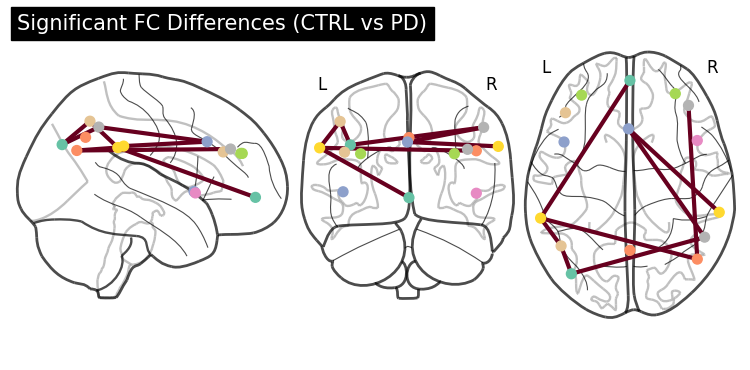

In [505]:
#@title Statistical Test CTRL vs PD
group_array = np.array(group)
idx_pd = group_array == "CTRL"
idx_pdd = group_array == "PD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
connection_matrix = get_connection(list_index)
coordinates = obtain_coordinates()
statistical_correction(p_values)
p_values[list_index]
#connection_matrix
#coordinates
plot_connections(connection_matrix, coordinates, group1 = "CTRL", group2 = "PD")

In [506]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "FC_CTRL_PD")

#**DYNAMIC FUNCTIONAL CONNECTIVITY**

In [507]:
#@title DYNAMIC FUNCTIONAL CONNECTIVITY
def dynamic_fc_from_roi(X, window_size=20, step_size=1):
    T, N = X.shape
    fc_windows = []

    taper = np.hamming(window_size)

    for start in range(0, T - window_size + 1, step_size):
        end = start + window_size

        Xw = X[start:end, :]           # (20, n_rois)
        Xw = Xw * taper[:, None]       # taper

        fc = np.corrcoef(Xw, rowvar=False)
        np.fill_diagonal(fc, 0.0)

        fc_windows.append(fc)

    return np.array(fc_windows)

In [508]:
def mean_block(fc, idx1, idx2):
    return fc[np.ix_(idx1, idx2)].mean()

In [509]:
TR = 2.5              # seconds
T = 240               # total timepoints
window_size = 20      # timesteps per window
step_size = 1         # shift in timesteps

In [510]:
window_indices = [] # to assign which timepoints we are gonna collect

for start in range(0, T - window_size + 1, step_size):
    end = start + window_size
    idx = np.arange(start, end)
    window_indices.append(idx)

window_indices = np.array(window_indices)

In [511]:
print("Number of windows:", len(window_indices))
print("Shape:", window_indices.shape)

Number of windows: 221
Shape: (221, 20)


In [512]:
print(window_indices[:5])
print(window_indices[-3:])

[[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
 [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
 [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
 [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
 [ 4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]]
[[218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235
  236 237]
 [219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236
  237 238]
 [220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237
  238 239]]


In [513]:
window_centers = (window_indices[:, 0] + window_size / 2) * TR

In [514]:
print(window_centers[:5])
print(window_centers[-5:])

[25.  27.5 30.  32.5 35. ]
[565.  567.5 570.  572.5 575. ]


In [515]:
for i in range(3):
    start = i
    center_time = (start + window_size / 2) * TR
    print(f"Window {i}: center at {center_time} s")

Window 0: center at 25.0 s
Window 1: center at 27.5 s
Window 2: center at 30.0 s


In [516]:
#@title Ctrl data
FC_dyn_ctrl = []
X_list_ctrl,roi_interest_names = get_list_roi_matrix(status = "CTRL")

for X in X_list_ctrl:
    fc_dyn = dynamic_fc_from_roi(X)   # (221, 15, 15)
    FC_dyn_ctrl.append(fc_dyn)

FC_dyn_ctrl = np.array(FC_dyn_ctrl)
FC_dyn_ctrl_z =  np.arctanh(FC_dyn_ctrl) # fisher

In [517]:
#@title PD data without depression
FC_dyn_pd = []
X_list_pd,roi_interest_names = get_list_roi_matrix(status = "PD")

for X in X_list_pd:
    fc_dyn = dynamic_fc_from_roi(X)
    FC_dyn_pd.append(fc_dyn)

FC_dyn_pd = np.array(FC_dyn_pd)

FC_dyn_pd_z =  np.arctanh(FC_dyn_pd) # fisher

In [518]:
#@title PD data with depression
FC_dyn_pd_dep = []
X_list_pd_dep,roi_interest_names = get_list_roi_matrix(status = "PDD")


for X in X_list_pd_dep:
    fc_dyn = dynamic_fc_from_roi(X)
    FC_dyn_pd_dep.append(fc_dyn)

FC_dyn_pd_dep = np.array(FC_dyn_pd_dep)
FC_dyn_pd_dep_z = np.arctanh(FC_dyn_pd_dep) # fisher

In [519]:
print(FC_dyn_ctrl.shape)
print(FC_dyn_pd.shape)
print(FC_dyn_pd_dep.shape)

(32, 221, 15, 15)
(32, 221, 15, 15)
(26, 221, 15, 15)


In [520]:
def flatten_fc(fc):
    return fc[np.triu_indices_from(fc, k=1)]

def extract_variability(subject_dfc):
  return np.var(subject_dfc, axis=0)

def mean_connectivity(subject_dfc):
  return np.mean(subject_dfc, axis=0)

def compute_var_connectivity(FC_dyn_z):
  list_variability = []
  list_mean_connect = []
  for subject_dfc in FC_dyn_z:
    #print(subject_dfc.shape)
    variability = extract_variability(subject_dfc)
    variability = flatten_fc(variability)
    list_variability.append(variability)
    #print(type(subject_dfc))
    mean_connect = mean_connectivity(subject_dfc)
    mean_connect = flatten_fc(mean_connect)
    list_mean_connect.append(mean_connect)
    #print(mean_connect.shape)
    #print(len(list_variability))
    #print(len(list_mean_connect))
  return list_variability, list_mean_connect

In [521]:
#@title Metrics CTRL
list_variability_ctrl, list_mean_connect_ctrl = compute_var_connectivity(FC_dyn_z = FC_dyn_ctrl_z)

both_metrics_ctrl = np.concatenate([np.array(list_variability_ctrl),np.array(list_mean_connect_ctrl)], axis = 1)
both_metrics_ctrl.shape

(32, 210)

In [522]:
#@title Metrics PD
list_variability_pd, list_mean_connect_pd = compute_var_connectivity(FC_dyn_z = FC_dyn_pd_z)

both_metrics_pd = np.concatenate([np.array(list_variability_pd),np.array(list_mean_connect_pd)], axis = 1)
both_metrics_pd.shape

(32, 210)

In [523]:
#@title Metrics PDD
list_variability_pd_dep, list_mean_connect_pd_dep = compute_var_connectivity(FC_dyn_z = FC_dyn_pd_dep_z)

both_metrics_pdd = np.concatenate([np.array(list_variability_pd_dep),np.array(list_mean_connect_pd_dep)], axis = 1)
both_metrics_pdd.shape

(26, 210)

In [524]:
#@title Combat Harmonization Variables
X = np.vstack([both_metrics_pd,both_metrics_pdd,both_metrics_ctrl])
group = ["PD"]*len(list_participants_pd) + ["PDD"]*len(list_participants_pdd) + ["CTRL"]* len(list_participants_ctrl)

batch_pd = get_manufacturers_list(list_participants_pd)
batch_pdd = get_manufacturers_list(list_participants_pdd)
batch_ctrl = get_manufacturers_list(list_participants_ctrl)
batch = np.concatenate([batch_pd, batch_pdd, batch_ctrl])
#batch_two = np.where(batch == "Manufacturer=Philips Medical Systems;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch)
#batch_two = np.where(batch_two == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch_two)

print(X.shape)
print(len(group))
print(len(batch))

(90, 210)
90
90


In [525]:
covars = pd.DataFrame({
    "SITE": batch,
    "GROUP": pd.Categorical(group).codes # 0 = ctrl, 1 = pd, 2 = pdd
})

In [526]:
y = pd.Categorical(group).codes

In [527]:
print(pd.Categorical(group).categories)

Index(['CTRL', 'PD', 'PDD'], dtype='object')


In [528]:
#print(covars.head())
model, X_harmonized = harmonizationLearn(
    data = X,
    covars = covars
)

In [529]:
print(X.shape, X_harmonized.shape)
print(np.isnan(X_harmonized).sum(), np.isinf(X_harmonized).sum())

(90, 210) (90, 210)
0 0


In [530]:
X_harmonized.shape

(90, 210)

In [531]:
print(model.keys())

dict_keys(['design', 'SITE_labels', 'var_pooled', 'B_hat', 'stand_mean', 'mod_mean', 'gamma_star', 'delta_star', 'info_dict', 'gamma_hat', 'delta_hat', 'gamma_bar', 't2', 'a_prior', 'b_prior', 'smooth_model', 'eb', 'SITE_labels_train', 'Covariates', 'ref_batch'])


In [532]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_harmonized)

Uncorrected: [ 70  72 142 186]
networks.Salience.AInsula (R) (47,14,0) <-> networks.Salience.RPFC (R) (32,46,27)
networks.Salience.AInsula (R) (47,14,0) <-> networks.Salience.SMG (R) (62,-35,32)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.FrontoParietal.LPFC (R)  (41,38,30)
networks.Salience.RPFC (L) (-32,45,27) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
Significant after FDR: 0


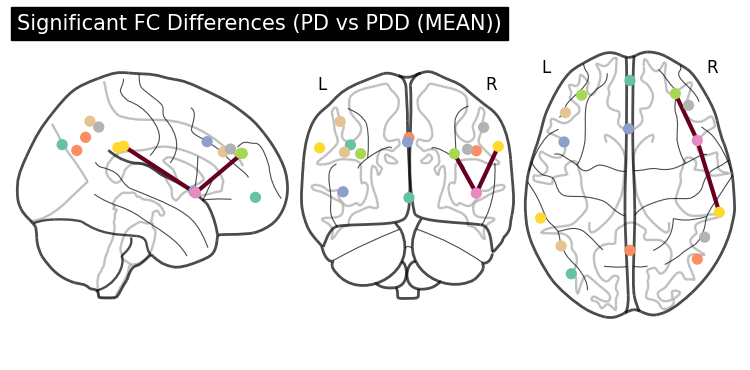

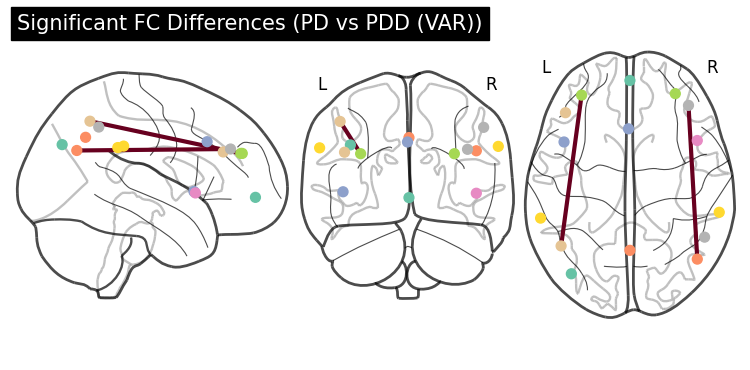

In [533]:
#@title Statistical Test PD vs PDD
group_array = np.array(group)
idx_1 = group_array == "PD"
idx_2 = group_array == "PDD"

p_values, list_index = statistical_test(X=X_harmonized, index_1=idx_1, index_2=idx_2)

mean_idx = [i for i in list_index if i < 105]
var_idx  = [i for i in list_index if i >= 105]
var_idx_adjusted = [i - 105 for i in var_idx]

matrix_mean = get_connection(mean_idx)
matrix_var  = get_connection(var_idx_adjusted)

coordinates = obtain_coordinates()

statistical_correction(p_values)

p_values[list_index]
plot_connections(matrix_mean, coordinates, group1="PD", group2="PDD (MEAN)")
plot_connections(matrix_var, coordinates, group1="PD", group2="PDD (VAR)")

In [534]:
save_to_plot(matrix_mean,coordinates,get_list_names(), name = "DC_PD_PDD_MEAN")
save_to_plot(matrix_var,coordinates,get_list_names(), name = "DC_PD_PDD_VARIABILITY")

In [535]:
#PD > PDD
for i in mean_idx:
    mean_pd = np.mean(X_harmonized[idx_1, i])
    mean_pdd = np.mean(X_harmonized[idx_2, i])

    print(i, "PD:", mean_pd, "PDD:", mean_pdd)

for i in var_idx:
    var_pd = np.mean(X_harmonized[idx_1, i])
    var_pdd = np.mean(X_harmonized[idx_2, i])

    print(i, "PD:", var_pd, "PDD:", var_pdd)

70 PD: 0.16363264467787553 PDD: 0.2025150142286642
72 PD: 0.14822968911532214 PDD: 0.1839870299709108
142 PD: 0.6753381967371193 PDD: 0.5634022964527169
186 PD: 0.4606697367469184 PDD: 0.592415792893693


Uncorrected: [ 19  61 106 113 123 133 135 136 137 138 139 142 149 155]
networks.DefaultMode.LP (L) (-39,-77,33) <-> networks.Salience.RPFC (L) (-32,45,27)
networks.Salience.AInsula (L) (-44,13,1) <-> networks.Salience.RPFC (L) (-32,45,27)
networks.DefaultMode.MPFC (1,55,-3) <-> networks.DefaultMode.LP (R) (47,-67,29)
networks.DefaultMode.MPFC (1,55,-3) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (L) (-39,-77,33) <-> networks.Salience.AInsula (R) (47,14,0)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.ACC (0,22,35)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.AInsula (R) (47,14,0)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.RPFC (L) (-32,45,27)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.RPFC (R) (32,46,27)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.SMG (R) (62,-35,32)
networks.DefaultMode.LP (R)

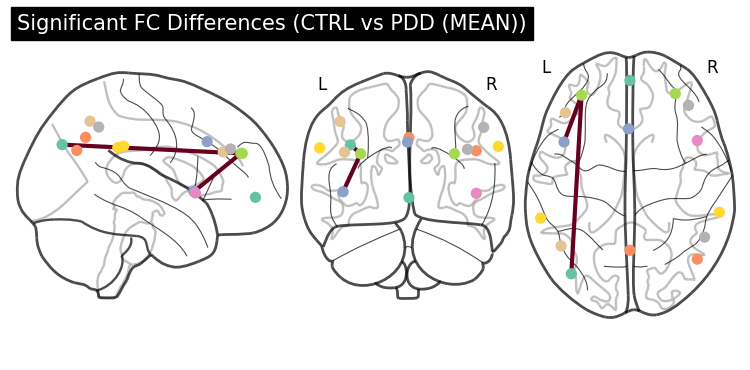

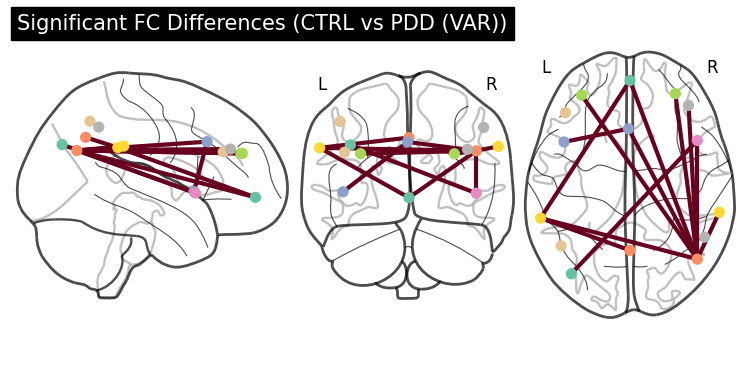

In [536]:
#@title Statistical Test CTRL vs PDD
group_array = np.array(group)
idx_1 = group_array == "CTRL"
idx_2 = group_array == "PDD"

p_values, list_index = statistical_test(X=X_harmonized, index_1=idx_1, index_2=idx_2)

mean_idx = [i for i in list_index if i < 105]
var_idx  = [i for i in list_index if i >= 105]

var_idx_adjusted = [i - 105 for i in var_idx]

matrix_mean = get_connection(mean_idx)
matrix_var  = get_connection(var_idx_adjusted)

coordinates = obtain_coordinates()

statistical_correction(p_values)

p_values[list_index]
plot_connections(matrix_mean, coordinates, group1="CTRL", group2="PDD (MEAN)")
plot_connections(matrix_var, coordinates, group1="CTRL", group2="PDD (VAR)")

In [537]:
save_to_plot(matrix_mean,coordinates,get_list_names(), name = "DC_CTRL_PDD_MEAN")
save_to_plot(matrix_var,coordinates,get_list_names(), name = "DC_CTRL_PDD_VARIABILITY")

In [538]:
# CTRL > PDD

for i in mean_idx:
    ctrl_val = np.mean(X_harmonized[idx_1, i])
    pdd_val  = np.mean(X_harmonized[idx_2, i])

    print(i, "CTRL:", ctrl_val, "PDD:", pdd_val)

for i in var_idx:
    ctrl_val = np.mean(X_harmonized[idx_1, i])
    pdd_val  = np.mean(X_harmonized[idx_2, i])

    print(i, "CTRL:", ctrl_val, "PDD:", pdd_val)

19 CTRL: 0.22208693366021318 PDD: 0.19285544651631611
61 CTRL: 0.17713622646841126 PDD: 0.1475943437538055
106 CTRL: 0.7136316614574099 PDD: 0.5753720201062409
113 CTRL: 0.28727543650787185 PDD: 0.05694080541297809
123 CTRL: 0.22199252335348668 PDD: 0.060044018209328504
133 CTRL: 0.4916904385666026 PDD: 0.30362611231483433
135 CTRL: 0.379602262071012 PDD: 0.20369432026607182
136 CTRL: 0.5058552504229834 PDD: 0.30426108919948924
137 CTRL: 0.5152600186102625 PDD: 0.3108416778442797
138 CTRL: 0.32730846308326256 PDD: 0.13627384391376768
139 CTRL: 0.4504742159791295 PDD: 0.26671576829123067
142 CTRL: 0.7552054737922949 PDD: 0.5634022964527169
149 CTRL: 0.46654673644335914 PDD: 0.33428255193388107
155 CTRL: 0.8674409050325297 PDD: 0.6747845988634812


Uncorrected: [ 24  36  46  47  72  80 110 113 129 131 135 138 197]
networks.DefaultMode.LP (L) (-39,-77,33) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
networks.DefaultMode.PCC (1,-61,38) <-> networks.FrontoParietal.LPFC (L)  (-43,33,28)
networks.DefaultMode.PCC (1,-61,38) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
networks.Salience.AInsula (R) (47,14,0) <-> networks.Salience.SMG (R) (62,-35,32)
networks.Salience.RPFC (L) (-32,45,27) <-> networks.FrontoParietal.LPFC (L)  (-43,33,28)
networks.DefaultMode.MPFC (1,55,-3) <-> networks.Salience.AInsula (R) (47,14,0)
networks.DefaultMode.MPFC (1,55,-3) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (L) (-39,-77,33) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
networks.DefaultMode.LP (L) (-39,-77,33) <-> networks.FrontoParietal.PPC (R)  (52,-52,45)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.AInsula

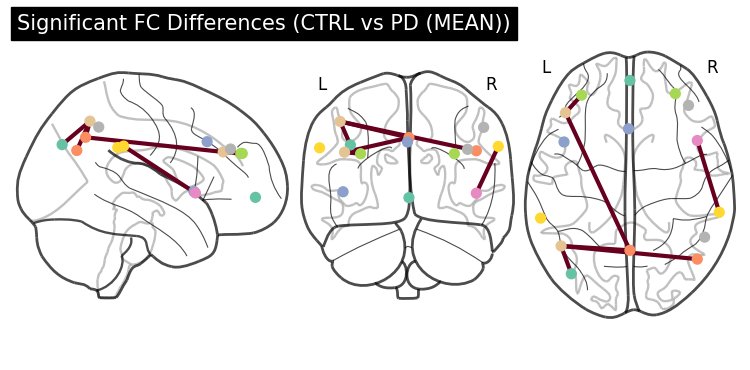

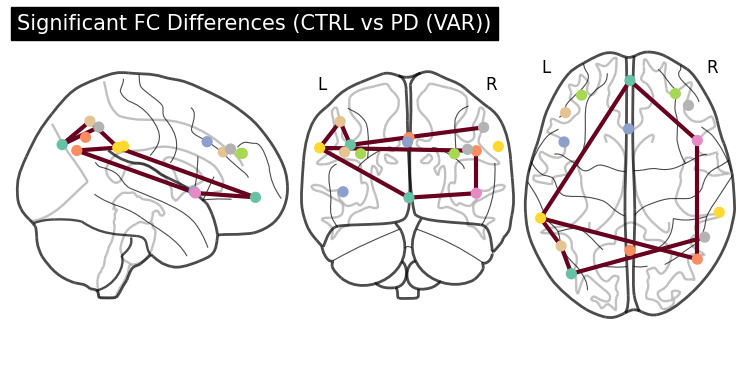

In [539]:
#@title Statistical Test CTRL vs PD
group_array = np.array(group)
idx_1 = group_array == "CTRL"
idx_2 = group_array == "PD"

p_values, list_index = statistical_test(X=X_harmonized, index_1=idx_1, index_2=idx_2)


mean_idx = [i for i in list_index if i < 105]
var_idx  = [i for i in list_index if i >= 105]
var_idx_adjusted = [i - 105 for i in var_idx]

matrix_mean = get_connection(mean_idx)
matrix_var  = get_connection(var_idx_adjusted)

coordinates = obtain_coordinates()

statistical_correction(p_values)

p_values[list_index]
plot_connections(matrix_mean, coordinates, group1="CTRL", group2="PD (MEAN)")
plot_connections(matrix_var, coordinates, group1="CTRL", group2="PD (VAR)")

In [540]:
save_to_plot(matrix_mean,coordinates,get_list_names(), name = "DC_CTRL_PD_MEAN")
save_to_plot(matrix_var,coordinates,get_list_names(), name = "DC_CTRL_PD_VARIABILITY")

In [541]:
# CTRL > PD

for i in mean_idx:
    ctrl_mean = np.mean(X_harmonized[idx_1, i])
    pd_mean   = np.mean(X_harmonized[idx_2, i])

    print(i, "CTRL_mean:", ctrl_mean, "PD_mean:", pd_mean)


for i in var_idx:
    ctrl_var = np.mean(X_harmonized[idx_1, i])
    pd_var   = np.mean(X_harmonized[idx_2, i])

    print(i, "CTRL_var:", ctrl_var, "PD_var:", pd_var)

24 CTRL_mean: 0.23577810460164095 PD_mean: 0.18810774236304384
36 CTRL_mean: 0.20826549899012864 PD_mean: 0.17970167046251512
46 CTRL_mean: 0.2343603332180284 PD_mean: 0.20488868371093466
47 CTRL_mean: 0.22844061235184746 PD_mean: 0.18601833524482547
72 CTRL_mean: 0.1868729736946772 PD_mean: 0.14822968911532214
80 CTRL_mean: 0.2304509813762662 PD_mean: 0.1853524474635836
110 CTRL_var: 0.40040288254938966 PD_var: 0.2179829178214737
113 CTRL_var: 0.28727543650787185 PD_var: 0.10856944431057704
129 CTRL_var: 0.8160597882653557 PD_var: 0.6840849153315063
131 CTRL_var: 0.5149443975549877 PD_var: 0.3780648641058315
135 CTRL_var: 0.379602262071012 PD_var: 0.22946072254825295
138 CTRL_var: 0.32730846308326256 PD_var: 0.18412024350498435
197 CTRL_var: 0.448355625520464 PD_var: 0.2910300331829393


#**EFFECTIVE FUNCTIONAL CONNECTIVITY**

In [627]:
def get_all_flatten_granger(G_list):
    nROI = G_list[0].shape[0]
    rows, cols = np.where(~np.eye(nROI, dtype=bool))
    features = []
    for G in G_list:
        vec = G[~np.eye(nROI, dtype=bool)]
        features.append(vec)

    return np.array(features), rows, cols

In [628]:
g_values = sio.loadmat(ROOT_PATH/"GC_results.mat")
g_values.keys()
G_ctrl = g_values['G_ctrl']
G_pd   = g_values['G_pd']
G_pdd  = g_values['G_pdd']
G_ctrl_list = [G_ctrl[i,0] for i in range(G_ctrl.shape[0])]
G_pd_list   = [G_pd[i,0] for i in range(G_pd.shape[0])]
G_pdd_list  = [G_pdd[i,0] for i in range(G_pdd.shape[0])]

In [629]:
matrix_flatten_ctrl, rows, cols = get_all_flatten_granger(G_ctrl_list)
matrix_flatten_pd, _, _         = get_all_flatten_granger(G_pd_list)
matrix_flatten_pdd, _, _        = get_all_flatten_granger(G_pdd_list)

In [630]:
print(matrix_flatten_ctrl.shape)
print(matrix_flatten_pd.shape)
print(matrix_flatten_pdd.shape)

(32, 210)
(32, 210)
(26, 210)


In [631]:
#@title Combat Harmonization Variables
X = np.vstack([matrix_flatten_pd,matrix_flatten_pdd,matrix_flatten_ctrl])
group = ["PD"]*len(list_participants_pd) + ["PDD"]*len(list_participants_pdd) + ["CTRL"]* len(list_participants_ctrl)

batch_pd = get_manufacturers_list(list_participants_pd)
batch_pdd = get_manufacturers_list(list_participants_pdd)
batch_ctrl = get_manufacturers_list(list_participants_ctrl)
batch = np.concatenate([batch_pd, batch_pdd, batch_ctrl])
#batch_two = np.where(batch == "Manufacturer=Philips Medical Systems;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch)
#batch_two = np.where(batch_two == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch_two)

print(X.shape)
print(len(group))
print(len(batch))

(90, 210)
90
90


In [632]:
covars = pd.DataFrame({
    "SITE": batch,
    "GROUP": pd.Categorical(group).codes # 0 = ctrl, 1 = pd, 2 = pdd
})
#print(covars.head())
model, X_harmonized = harmonizationLearn(
    data = X,
    covars = covars
)

In [633]:
print(X.shape, X_harmonized.shape)
print(np.isnan(X_harmonized).sum(), np.isinf(X_harmonized).sum())

(90, 210) (90, 210)
0 0


In [634]:
def statistical_test_uncorrected(X, idx_1, idx_2):
    p_values = []

    for i in range(X.shape[1]):  # loop over edges
        x1 = X[idx_1, i]
        x2 = X[idx_2, i]

        _, p = mannwhitneyu(x1, x2, alternative="two-sided")
        p_values.append(p)

    p_values = np.array(p_values)

    # uncorrected significance
    list_index = np.where(p_values < 0.05)[0]

    print("Significant (uncorrected):", len(list_index))

    return p_values, list_index

def get_connection(list_index, rows, cols, roi_names):
    n_rois = len(roi_names)
    matrix = np.zeros((n_rois, n_rois), dtype=int)

    for idx in list_index:
        i = rows[idx]
        j = cols[idx]

        print(f"{roi_names[i]} → {roi_names[j]}")
        matrix[i, j] = 1   # directed edge

    return matrix


Significant (uncorrected): 4
networks.Salience.AInsula (R) (47,14,0) → networks.Salience.RPFC (R) (32,46,27)
networks.Salience.RPFC (L) (-32,45,27) → networks.Salience.AInsula (L) (-44,13,1)
networks.FrontoParietal.LPFC (L)  (-43,33,28) → networks.DefaultMode.LP (L) (-39,-77,33)
networks.FrontoParietal.PPC (R)  (52,-52,45) → networks.DefaultMode.PCC (1,-61,38)


/tmp/ipykernel_10327/1646545693.py:2: UserWarning:

'adjacency_matrix' is not symmetric.
A directed graph will be plotted.



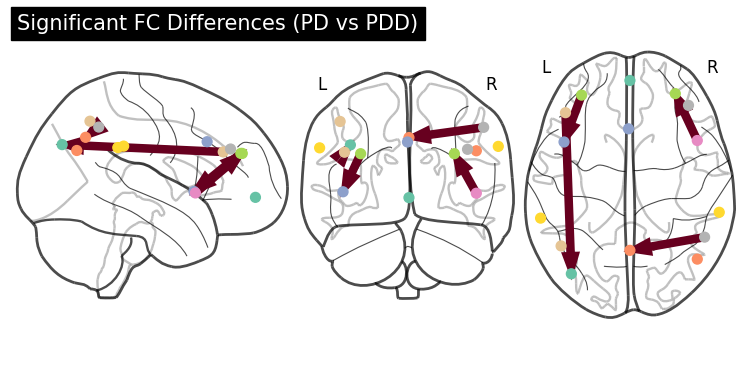

In [635]:
#@title Statistical Test PD vs PDD
group_array = np.array(group)

idx_pd  = group_array == "PD"
idx_pdd = group_array == "PDD"

p_values, list_index = statistical_test_uncorrected(
    X_harmonized,
    idx_pd,
    idx_pdd
)

roi_names = get_roi_names()
connection_matrix = get_connection(list_index, rows, cols, roi_names)
coordinates = obtain_coordinates()
plot_connections(connection_matrix, coordinates, group1="PD", group2="PDD")

In [636]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "GC_PD_PDD")

Significant (uncorrected): 10
networks.DefaultMode.LP (L) (-39,-77,33) → networks.Salience.AInsula (L) (-44,13,1)
networks.DefaultMode.LP (R) (47,-67,29) → networks.DefaultMode.MPFC (1,55,-3)
networks.DefaultMode.PCC (1,-61,38) → networks.DefaultMode.MPFC (1,55,-3)
networks.Salience.ACC (0,22,35) → networks.DefaultMode.LP (L) (-39,-77,33)
networks.Salience.RPFC (L) (-32,45,27) → networks.FrontoParietal.PPC (R)  (52,-52,45)
networks.Salience.SMG (L) (-60,-39,31) → networks.DefaultMode.LP (L) (-39,-77,33)
networks.Salience.SMG (R) (62,-35,32) → networks.DefaultMode.LP (L) (-39,-77,33)
networks.FrontoParietal.LPFC (L)  (-43,33,28) → networks.DefaultMode.MPFC (1,55,-3)
networks.FrontoParietal.LPFC (R)  (41,38,30) → networks.FrontoParietal.PPC (R)  (52,-52,45)
networks.FrontoParietal.PPC (R)  (52,-52,45) → networks.DefaultMode.LP (L) (-39,-77,33)


/tmp/ipykernel_10327/1646545693.py:2: UserWarning:

'adjacency_matrix' is not symmetric.
A directed graph will be plotted.



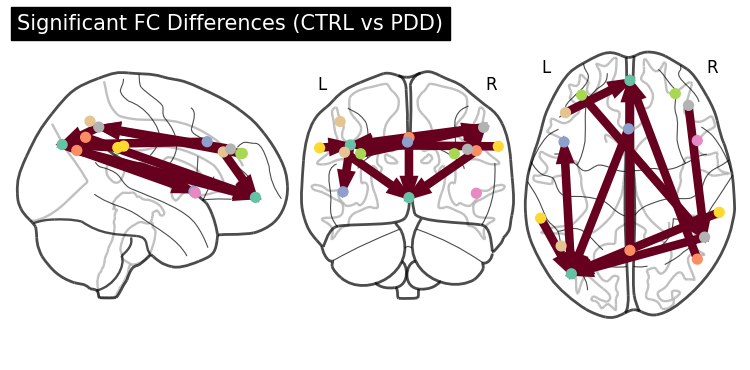

In [637]:
#@title Statistical Test CTRL vs PDD
group_array = np.array(group)

idx_ctrl  = group_array == "CTRL"
idx_pdd = group_array == "PDD"

p_values, list_index = statistical_test_uncorrected(
    X_harmonized,
    idx_ctrl,
    idx_pdd
)

roi_names = get_roi_names()
connection_matrix = get_connection(list_index, rows, cols, roi_names)
coordinates = obtain_coordinates()
plot_connections(connection_matrix, coordinates, group1="CTRL", group2="PDD")

In [638]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "GC_CTRL_PDD")

Significant (uncorrected): 8
networks.DefaultMode.LP (R) (47,-67,29) → networks.DefaultMode.MPFC (1,55,-3)
networks.Salience.AInsula (R) (47,14,0) → networks.Salience.AInsula (L) (-44,13,1)
networks.Salience.AInsula (R) (47,14,0) → networks.Salience.RPFC (R) (32,46,27)
networks.Salience.RPFC (L) (-32,45,27) → networks.FrontoParietal.PPC (R)  (52,-52,45)
networks.Salience.SMG (R) (62,-35,32) → networks.Salience.RPFC (L) (-32,45,27)
networks.Salience.SMG (R) (62,-35,32) → networks.FrontoParietal.LPFC (R)  (41,38,30)
networks.FrontoParietal.LPFC (L)  (-43,33,28) → networks.DefaultMode.LP (L) (-39,-77,33)
networks.FrontoParietal.PPC (R)  (52,-52,45) → networks.DefaultMode.PCC (1,-61,38)


/tmp/ipykernel_10327/1646545693.py:2: UserWarning:

'adjacency_matrix' is not symmetric.
A directed graph will be plotted.



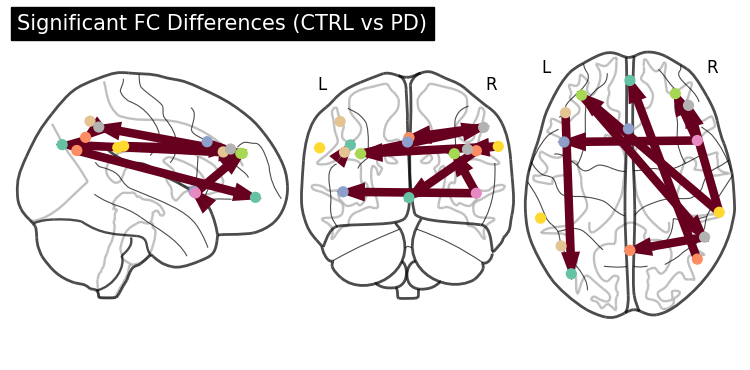

In [639]:
#@title Statistical Test CTRL vs PD
group_array = np.array(group)

idx_ctrl  = group_array == "CTRL"
idx_pd = group_array == "PD"

p_values, list_index = statistical_test_uncorrected(
    X_harmonized,
    idx_ctrl,
    idx_pd
)

roi_names = get_roi_names()
connection_matrix = get_connection(list_index, rows, cols, roi_names)
coordinates = obtain_coordinates()
plot_connections(connection_matrix, coordinates, group1="CTRL", group2="PD")

In [640]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "GC_CTRL_PD")

#**BRAIN GLASS**

In [555]:
coordinates = obtain_coordinates()
names_list = get_list_names()
color_list = get_colors(len(coordinates))

view = plotting.view_markers(
    marker_coords=coordinates,
    marker_labels=names_list,
    marker_color=color_list,
    marker_size = 10,
    title = "Regions of Interest (ROIs) Included in the Analysis"
)
view

In [556]:
get_list_names()

['DMN.MPFC',
 'DMN.LP (L)',
 'DMN.LP (R)',
 'DMN.PCC',
 'SAL.ACC',
 'SAL.AInsula (L)',
 'SAL.AInsula (R)',
 'SAL.RPFC (L)',
 'SAL.RPFC (R)',
 'SAL.SMG (L)',
 'SAL.SMG (R)',
 'FPN.LPFC (L)',
 'FPN.PPC (L)',
 'FPN.LPFC (R)',
 'FPN.PPC (R)']